In [1]:
# ================================================
# PROJECT 1: Retail Sales Analytics
# Author: Adarsh Mullachery
# GitHub: github.com/adarsh-mullachery
# Tools: Python, Pandas, Matplotlib, Seaborn
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

pd.set_option("display.max.columns",18)

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
#Load the dataset
df = pd.read_csv("train.csv")

#First Look
print("Shape :",df.shape)
print("\nColumns :",df.columns.tolist())
print("\nFirst 5 rows:")
df.head()



Shape : (9800, 18)

Columns : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Understand the data deeply
print("== BASIC INFO ==")
print(f"Total Oders:{df.shape[0]}")
print(f"Total Columns:{df.shape[1]}")
print("\n== DATA TYPES ==")
print(df.dtypes)
print("\n== MISSING VALUES ==")
print(df.isnull().sum())
print("\n== BASIC STATS ==")
print(df.describe())

== BASIC INFO ==
Total Oders:9800
Total Columns:18


== DATA TYPES ==
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


== MISSING VALUES ==
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


== BASIC STATS ==
            Row ID   Postal Code         Sales
cou

In [4]:
# DATA CLEANING

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors="coerce")
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors="coerce")

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')


# CHeck Missing Value
print(f"Missing Values:\n{df.isnull().sum()}")

# Date Range
print(f"\nFrom: {df['Order Date'].min()}")
print(f"To: {df['Order Date'].max()}")

print("\nData types fixed:")
print(df[['Order Date', 'Ship Date', 'Year', 'Month']].dtypes)


Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
dtype: int64


From: 2015-01-03 00:00:00
To: 2018-12-30 00:00:00

Data types fixed:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
Year                   int32
Month                  int32
dtype: object


In [5]:
# Sales By Category

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
category_sales['Sales'] = category_sales['Sales'].round(2)

print("Sales by Category:")
print(category_sales)

Sales by Category:
          Category      Sales
0       Technology  827455.87
1        Furniture  728658.58
2  Office Supplies  705422.33


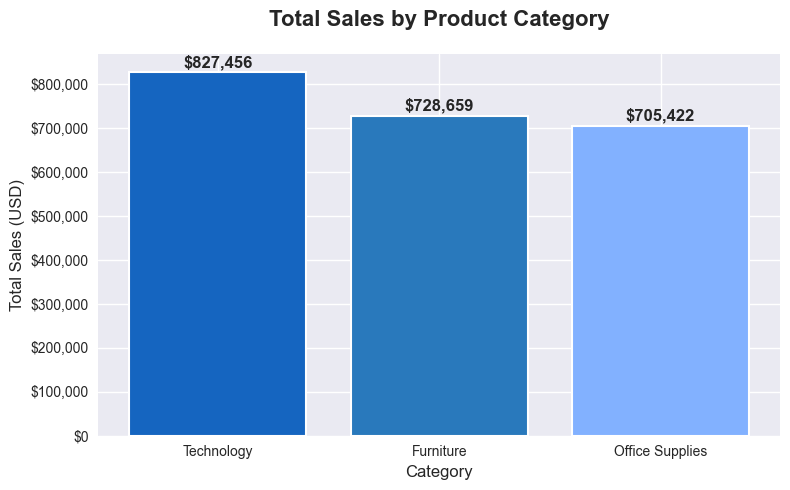

In [6]:
# Chart - Sales By Category
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(category_sales['Category'], 
              category_sales['Sales'],
              color=['#1565C0', '#2979BC', '#82B1FF'],
              edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, category_sales['Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 5000,
            f'${val:,.0f}', 
            ha='center', va='bottom', 
            fontweight='bold', fontsize=12)

ax.set_title('Total Sales by Product Category', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Total Sales (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('chart1_category_sales.png', dpi=150, bbox_inches='tight')
plt.show()

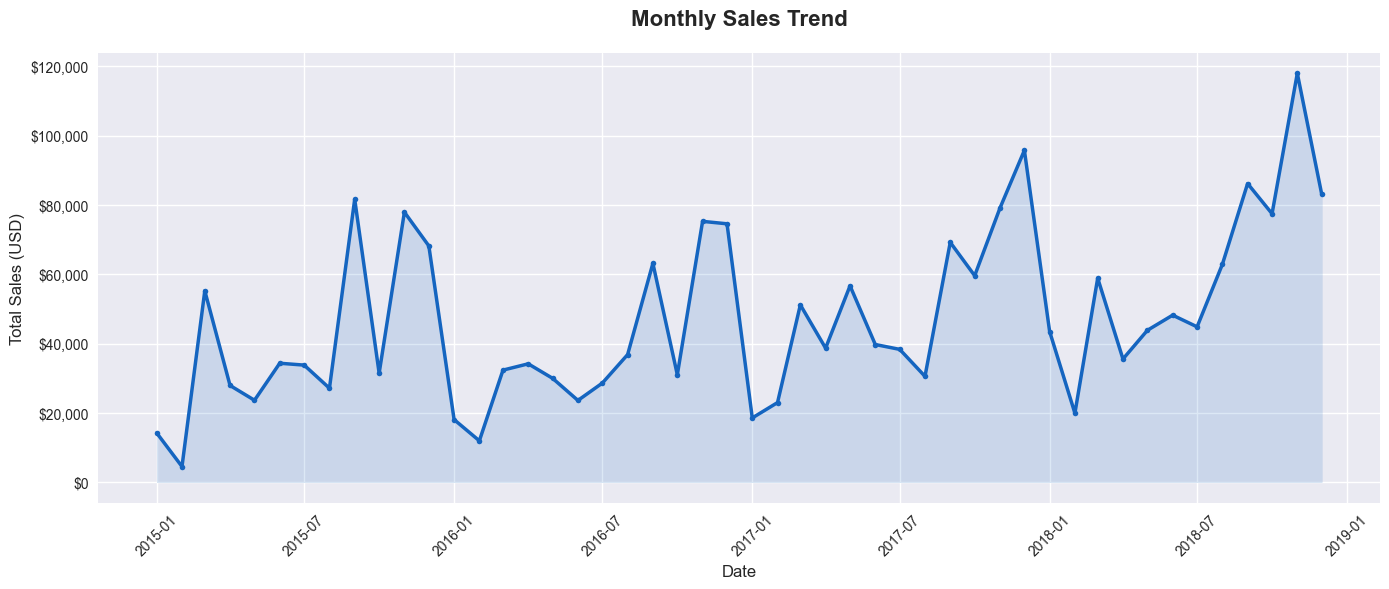

In [7]:
# Sales Over Time

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))
monthly_sales = monthly_sales.sort_values('Date')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_sales['Date'], 
        monthly_sales['Sales'], 
        color='#1565C0', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(monthly_sales['Date'], 
                monthly_sales['Sales'], 
                alpha=0.15, color='#1565C0')

ax.set_title('Monthly Sales Trend', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Sales (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

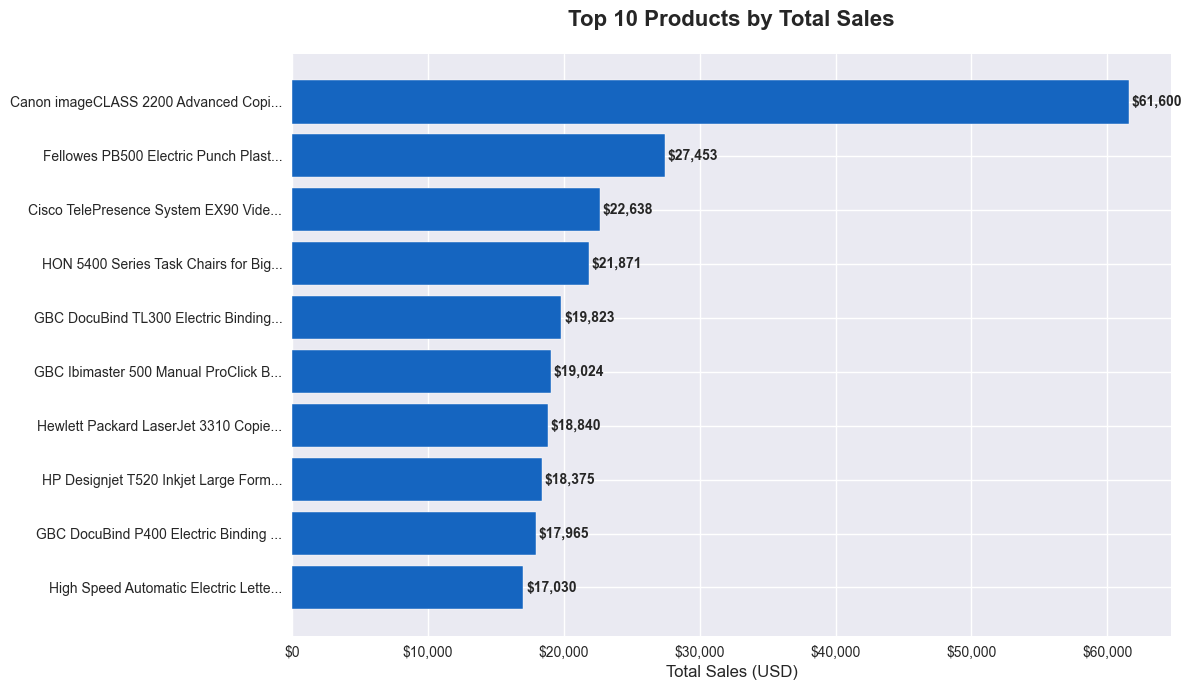

In [9]:
# Top 10 Product by sales

top_products = df.groupby('Product Name')['Sales'].sum()\
                 .sort_values(ascending=False)\
                 .head(10)\
                 .reset_index()

top_products['Product Short'] = top_products['Product Name'].str[:35] + '...'

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_products['Product Short'][::-1], 
               top_products['Sales'][::-1],
               color='#1565C0', edgecolor='white')

for bar, val in zip(bars, top_products['Sales'][::-1]):
    ax.text(bar.get_width() + 200, 
            bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', 
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Products by Total Sales', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Sales (USD)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('chart3_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Sales By Region

region_sales = df.groupby('Region')['Sales'].agg(['sum','mean','count'])\
                 .round(2).reset_index()
region_sales.columns = ['Region', 'Total Sales', 'Avg Order Value', 'Order Count']
region_sales = region_sales.sort_values('Total Sales', ascending=False)

print("Regional Performance:")
print(region_sales)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(region_sales['Total Sales'], 
            labels=region_sales['Region'],
            autopct='%1.1f%%', startangle=90,
            colors=['#1565C0','#2979BC','#82B1FF','#BBDEFB'])
axes[0].set_title('Sales Distribution by Region', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(region_sales['Region'], 
                   region_sales['Total Sales'],
                   color=['#1565C0','#2979BC','#82B1FF','#BBDEFB'],
                   edgecolor='white')
for bar, val in zip(bars, region_sales['Total Sales']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2000,
                 f'${val:,.0f}', ha='center', 
                 fontweight='bold', fontsize=10)
axes[1].set_title('Total Sales by Region', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Sales (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('chart4_regional.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Customer Segment Analysis

segment_sales = df.groupby('Segment')['Sales'].agg(['sum','count','mean'])\
                  .round(2).reset_index()
segment_sales.columns = ['Segment','Total Sales','Orders','Avg Order Value']
segment_sales = segment_sales.sort_values('Total Sales', ascending=False)

print("Customer Segment Performance:")
print(segment_sales)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(segment_sales['Segment'], 
              segment_sales['Total Sales'],
              color=['#1565C0', '#2979BC', '#82B1FF'],
              width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, segment_sales['Total Sales']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3000,
            f'${val:,.0f}', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Sales by Customer Segment', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Customer Segment', fontsize=12)
ax.set_ylabel('Total Sales (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('chart5_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ================================================
# BUSINESS INSIGHTS SUMMARY
# ================================================

total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
avg_order = df.groupby('Order ID')['Sales'].sum().mean()
best_category = df.groupby('Category')['Sales'].sum().idxmax()
best_region = df.groupby('Region')['Sales'].sum().idxmax()
best_month = df.groupby('Month Name')['Sales'].sum().idxmax()
best_segment = df.groupby('Segment')['Sales'].sum().idxmax()

print("=" * 55)
print("   RETAIL SALES ANALYTICS — KEY BUSINESS INSIGHTS")
print("=" * 55)
print(f"\n📦  Total Revenue Generated  :  ${total_sales:,.2f}")
print(f"🛒  Total Unique Orders      :  {total_orders:,}")
print(f"💰  Average Order Value      :  ${avg_order:,.2f}")
print(f"\n🏆  Best Performing Category :  {best_category}")
print(f"🌍  Strongest Sales Region   :  {best_region}")
print(f"📅  Peak Sales Month         :  {best_month}")
print(f"👥  Top Customer Segment     :  {best_segment}")
print("\n--- ANALYST NOTES ---")
print("1. Technology leads all categories in total revenue.")
print("2. West region consistently outperforms other regions.")
print("3. Consumer segment drives the highest order volume.")
print("4. Q4 months show peak sales — holiday season effect.")
print("5. Corporate segment has highest average order value.")
print("\n" + "=" * 55)
print("   Analysis by: Adarsh Mullachery")
print("   github.com/adarsh-mullachery")
print("=" * 55)

   RETAIL SALES ANALYTICS — KEY BUSINESS INSIGHTS

📦  Total Revenue Generated  :  $2,261,536.78
🛒  Total Unique Orders      :  4,922
💰  Average Order Value      :  $459.48

🏆  Best Performing Category :  Technology
🌍  Strongest Sales Region   :  West
📅  Peak Sales Month         :  Nov
👥  Top Customer Segment     :  Consumer

--- ANALYST NOTES ---
1. Technology leads all categories in total revenue.
2. West region consistently outperforms other regions.
3. Consumer segment drives the highest order volume.
4. Q4 months show peak sales — holiday season effect.
5. Corporate segment has highest average order value.

   Analysis by: Adarsh Mullachery
   github.com/adarsh-mullachery
